# Ch11. 앙상블 모델

- 여러 알고리듬을 결합해 각 엔진(학습자)에서 가치 추출

[11.1] 선형 앙상블
- M개의 모델로 작업
- $\tilde{y}_{i,m}$: 인스턴스 i에 대한 모델 m의 예측값
- 오차 $\epsilon_{i,m}=y_i-\tilde{y}_{i,m}$: $(I\times M)$ 크기의 행렬 $\textbf{E}$
- 모델의 선형 조합, 표본 오차: $\textbf{Ew}$ ~ 각 모델에 할당된 가중치
$\\ \therefore$ 전체 (제곱) 오차 최소화: 고유한 제약조건(가중치 합=1)이 있는 이차 계획법
$\\$: $\frac{\partial}{\partial \textbf{w}}L(\textbf{w})=\textbf{E}'\textbf{E}\textbf{w}-\lambda \textbf{1}_M=0 \quad \Leftrightarrow \quad \textbf{w}=\lambda(\textbf{E}'\textbf{E})^{-1}\textbf{1}_M$
$\\$ Result: $\textbf{w}^*=\frac{(\textbf{E}'\textbf{E})^{-1}\textbf{1}_M}{(\textbf{1}_M'\textbf{E}'\textbf{E})^{-1}\textbf{1}_M}$
- 최적화된 선형 앙상블의 특징을 보여줌: 모델이 서로 다른 이야기를 할 때만 가치를 더할 수 있음
- 두 모델이 중복되면 $\textbf{E}'\textbf{E}$는 특이 행렬에 가까워짐

(\*) 상관관계로 인한 문제
1. 상관계수 증가 -> 공식 불안정해짐
$\\ \textbf{E}'\textbf{E}=\left[
\begin{array}{cc} \sigma_1^2 & \rho\sigma_1\sigma_2 \\
\rho\sigma_1\sigma_2 & \sigma_2^2 \\
\end{array}
\right] \quad \Leftrightarrow  \quad
(\textbf{E}'\textbf{E})^{-1}=\frac{1}{1-\rho^2}\left[
\begin{array}{cc} \sigma_1^{-2} & -\rho(\sigma_1\sigma_2)^{-1} \\
-\rho(\sigma_1\sigma_2)^{-1} & \sigma_2^{-2} \\
\end{array}
\right]$
- $\rho \rightarrow 1$, 오차 가장 작은 모델: 가중치 무한대 / 다른 모델: 음의 가중치
2. 쌍별 상관관계
$\\ \mathbb{E}\left[\frac{1}{M}\sum_{m=1}^M \epsilon_m^2 \right]=\frac{1}{M^2}\left[\sum_{m=1}^M\epsilon_m^2+\sum_{m\neq n}\epsilon_n\epsilon_m\right] \\ =\frac{\sigma^2}{M}+\frac{1}{M^2}\sum_{n\neq m} \rho \sigma^2 \\ \rho \sigma^2 +\frac{\sigma^2(1-\rho)}{M}$
- 오차의 분산: $\rho$에 따라 선형적 증가 

(\*) 상관계수 문제 해결 방안: 가중치에 양수 제약
$\\ \underset{\mathbf{w}}{\operatorname{argmin}} \: \mathbf{w}^\top \mathbf{E}^\top \mathbf{E} \mathbf{w} \quad \text{s.t.} \quad
\begin{cases} 
\mathbf{w}^\top \mathbf{1}_M = 1 \\ 
w_m \ge 0, \quad \forall m 
\end{cases}$

In [1]:
import import_ipynb

In [ ]:
from Ch1 import data_ml, idx_train, idx_test, features
from sklearn.linear_model import ElasticNet
training_sample=data_ml[data_ml.index.isin(idx_train)]
testing_sample=data_ml[data_ml.index.isin(idx_test)]

y_penalized_train=training_sample['R1M_Usd'].values
X_penalized_trian=training_sample[features].values
model=ElasticNet(alpha=0.1, l1_ratio=0.1)
fit_pen_pred=model.fit(X_penalized_trian, y_penalized_train)

In [3]:
from sklearn import tree
fit_tree=tree.DecisionTreeRegressor( # 모델 정의
    min_samples_split=8000, # 분할 지속 위한 최소 관측치 개수
    max_depth=3, # 최대 깊이(: 트리 레벨) ~ 최대 3번의 분할이 있어야 함
    ccp_alpha=0.000001, # 복잡도 매개 변수: 분할 전의 0.9999배 이하로 손실 줄여야 함
    min_samples_leaf=3500 # 각 최종 노드에 필요한 관측치 최소 개수(나뭇잎)
)

In [9]:
X=data_ml.iloc[:,3:95] # 특성/예측 인자
y=data_ml['R1M_Usd'] # 레이블/종속 변수
fit_tree.fit(X,y) # 모델 피팅

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,8000
,min_samples_leaf,3500
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,1e-06


In [11]:
from sklearn.ensemble import RandomForestRegressor
fit_RF=RandomForestRegressor(n_estimators=40, # 랜덤 트리의 개수
                             criterion='squared_error', # 분할 퀄리티 측정을 위한 함수
                             min_samples_split=250, # 최종 클러스터의 최소 사이즈
                             min_samples_leaf=250,
                             bootstrap=True,
                             max_features=30, # 각 트리별 예측 변수의 개수 (30개 정보만 보고 판단)
                             max_samples=10000, # 각 트리별 (랜덤) 샘플의 사이즈
                             )
y_train=training_sample['R1M_Usd'].values
X_train=training_sample[features].values
fit_RF.fit(X_train, y_train)

,n_estimators,40
,criterion,'squared_error'
,max_depth,None
,min_samples_split,250
,min_samples_leaf,250
,min_weight_fraction_leaf,0.0
,max_features,30
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
import xgboost as xgb # 부스팅 트리 위한 패키지
import pandas as pd
from Ch1 import features_short
'''
data_ml['R1M_Usd_quantile']=data_ml.groupby('date')['R1M_Usd'].transform(
    lambda x: pd.qcut(x, 100, labels=False,
                      duplicates=('drop'), precision=50)
)
from Ch1 import separation_date, features_short
separation_mask=data_ml['date'] < separation_date

boolean_quantile=(
    data_ml.loc[separation_mask]['R1M_Usd_quantile'].values<=20)|(
        data_ml.loc[separation_mask]['R1M_Usd_quantile'].values>=80
    )
'''
train_features_xgb=training_sample.loc[:, features_short]
train_label_xgb=training_sample.loc[:,'R1M_Usd']
train_matrix_xgb=xgb.DMatrix(train_features_xgb, label=train_label_xgb)
mono_const="(0,0,-1,1,0,-1,0)"
params={'eta':0.3,
        'objective':'reg:squarederror', #목적함수
        'max_depth':4, # 각 트리 최고 깊이
        'subsample':0.6, # 샘플 중 무작위로 60% 선택해 훈련
        'colsample_bytree':0.7, # 예측 인자 중 무작위로 70% 선택해 훈련
        'lambda':1,
        'gamma':0.1,
        'nrounds':30, # 사용한 트리 개수
        'monotone_constraints': mono_const, # 단조성 제약 조건: 상식 주입 과정
        'rate_drop': 0.1, # DART 위한 드롭률
        'verbose':0
        }
fit_xgb=xgb.train(params, train_matrix_xgb)

c:\Users\82103\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:58:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "nrounds", "rate_drop", "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
NN_train_features=training_sample[features].values
NN_train_labels=training_sample['R1M_Usd'].values
NN_test_featurs=testing_sample[features].values
NN_test_labels=testing_sample['R1M_Usd'].values

from tensorflow import keras
from tensorflow.keras import layers
model=keras.Sequential()
model.add(layers.Dense(16, activation='relu',input_shape=(len(features),))) # input_shape: 첫 번째 층계에서만 필요
model.add(layers.Dense(8,activation='tanh')) # 양/음수 출력 모두 생성 ~ 마지막에서 두 번째 층계에 사용
model.add(layers.Dense(1))

model.compile(optimizer='RMSprop', # 고전적인 미니 배치 역전파 구현(가중치 업데이트 알고리듬)
              loss='mse',
              metrics=['MeanAbsoluteError']) 
model.fit(
    NN_train_features,
    NN_train_labels,
    batch_size=256, # GPU 훈련과 관련된 기술적 이유로 2의 거듭제곱인 경우가 많음
    epochs=10,
    validation_data=(NN_test_featurs,NN_test_labels),
    verbose=True
)

c:\Users\82103\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
c:\Users\82103\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - MeanAbsoluteError: 0.0871 - loss: 0.0299 - val_MeanAbsoluteError: 0.0665 - val_loss: 0.0370
Epoch 2/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - MeanAbsoluteError: 0.0841 - loss: 0.0290 - val_MeanAbsoluteError: 0.0668 - val_loss: 0.0370
Epoch 3/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - MeanAbsoluteError: 0.0840 - loss: 0.0290 - val_MeanAbsoluteError: 0.0669 - val_loss: 0.0370
Epoch 4/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - MeanAbsoluteError: 0.0839 - loss: 0.0289 - val_MeanAbsoluteError: 0.0669 - val_loss: 0.0370
Epoch 5/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - MeanAbsoluteError: 0.0839 - loss: 0.0289 - val_MeanAbsoluteError: 0.0673 - val_loss: 0.0370
Epoch 6/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - MeanAbsoluteError: 0.0839 - loss: 0.0289 - val_MeanAbsoluteError: 0.0668 - val_loss: 0.0370
Epoch 7/10
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - MeanAbsoluteError: 0.0839 - loss: 0.0289 - val_MeanAbsoluteError: 0.06

In [ ]:
# 앙상블 구축하려면 예측 & 그에 상응하는 오차를 행렬에 모아야 함
# 훈련 오차 평균이 0이면 E'E: 모델간 오차의 공분산 행렬

In [18]:
err_pen_train=fit_pen_pred.predict(
    X_penalized_trian
)-training_sample['R1M_Usd'] # 회귀
err_tree_train=fit_tree.predict(
    training_sample[features]
)-training_sample['R1M_Usd'] # 트리
err_RF_train=fit_RF.predict(
    training_sample[features]
)-training_sample['R1M_Usd'] # 랜덤 포레스트
err_XGB_train=fit_xgb.predict(
    train_matrix_xgb
)-training_sample['R1M_Usd'] # XGBoost
err_NN_train=model.predict(
    NN_train_features
).flatten()-training_sample['R1M_Usd'] # 신경망

c:\Users\82103\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


6192/6192 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


In [22]:
E=pd.concat(
    [err_pen_train, err_tree_train, err_RF_train, err_XGB_train, pd.DataFrame(err_NN_train)], axis=1) # E 행렬
E=E.set_axis(['Pen_reg','Tree','RF','XGB','NN'], axis=1)
E.corr()

,Pen_reg,Tree,RF,XGB,NN
Pen_reg,1.000000,0.998439,0.998336,0.993999,0.997736
Tree,0.998439,1.000000,0.998739,0.995171,0.998090
RF,0.998336,0.998739,1.000000,0.995298,0.998823
XGB,0.993999,0.995171,0.995298,1.000000,0.994631
NN,0.997736,0.998090,0.998823,0.994631,1.000000


In [23]:
E.corr().mean()

Pen_reg    0.997702
Tree       0.998088
RF         0.998239
XGB        0.995820
NN         0.997856
dtype: float64

In [24]:
# 오차 평균 절댓값 => 모델의 학습 정확도 비교
abs(E).mean()

Pen_reg    0.083459
Tree       0.083621
RF         0.083472
XGB        0.083761
NN         0.083923
dtype: float64

In [25]:
# 모델 결합에 대한 최적의 가중치 계산
import numpy as np
w_ensemble=np.linalg.inv((E.T.values@E.values))@np.ones(5)
w_ensemble/=np.sum(w_ensemble)
w_ensemble

array([-0.46953274, -0.6399253 ,  0.11934377,  1.56149684,  0.42861743])

In [30]:
X_penalized_test=testing_sample[features].values
test_features_xgb=testing_sample[features_short]
y_test=testing_sample['R1M_Usd'].values
test_matrix_xgb=xgb.DMatrix(test_features_xgb, label=y_test)
NN_test_featurs=testing_sample[features].values

In [32]:
err_pen_test=fit_pen_pred.predict(
    X_penalized_test
)-testing_sample['R1M_Usd'] # 회귀
err_tree_test=fit_tree.predict(
    testing_sample[features]
)-testing_sample['R1M_Usd'] # 트리
err_RF_test=fit_RF.predict(
    testing_sample[features]
)-testing_sample['R1M_Usd'] # 랜덤 포레스트
err_XGB_test=fit_xgb.predict(
    test_matrix_xgb
)-testing_sample['R1M_Usd'] # XGBoost
err_NN_test=model.predict(
    NN_test_featurs
).flatten()-testing_sample['R1M_Usd'] # 신경망

c:\Users\82103\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


2194/2194 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [33]:
E_test=pd.concat([err_pen_test, err_tree_test, err_RF_test, err_XGB_test, pd.DataFrame(err_NN_test, index=testing_sample.index)], axis=1)
E_test=E_test.set_axis(['Pen_reg','Tree','RF','XGB','NN'], axis=1)
err_EW_test=np.mean(np.abs(E_test.mean(axis=1)))
err_opt_test=np.mean(np.abs(E_test.values@w_ensemble))

In [26]:
!pip install cvxopt

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.8 MB 23.8 MB/s eta 0:00:01
   --------------------------- ------------ 8.9/12.8 MB 29.2 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 27.9 MB/s  0:00:00


In [ ]:
# 이차 최적화
from cvxopt import matrix, solvers # 이차 계획법을 위한 라이브러리
sigma=E.T.values@E.values # 스케일링되지 않은 공분산 행렬
nb_mods=5 # 모델 개수
# 대칭적 이차-비용 행렬
Q=2*matrix(sigma, tc='d')
# 이차-비용 벡터
p=matrix(np.zeros(nb_mods), tc='d') # 1차항의 계수 0
# 선형 부등식 제약 행렬(비음 제약)
G=matrix(-np.eye(nb_mods), tc='d')
# 선형부등식 제약 벡터
h=matrix(np.zeros(nb_mods), tc='d')
# 선형 등식 제약 조건 위한 행력
A=matrix(np.ones(nb_mods), (1, nb_mods)) # value, size
# 선형 등식 제약 조건 위한 벡터
b=matrix(1.0)
# 솔루션
w_const=solvers.qp(Q,p,G,h,A,b)
print(w_const['x'])


     pcost       dcost       gap    pres   dres
 0:  5.5809e+03  5.5815e+03  2e+01  4e+00  6e+00
 1:  5.5812e+03  5.5849e+03  4e+00  1e+00  2e+00
 2:  5.5863e+03  5.5956e+03  7e+00  7e-01  1e+00
 3:  5.6015e+03  5.6071e+03  8e+00  2e-01  4e-01
 4:  5.6089e+03  5.6087e+03  1e+01  1e-01  2e-01
 5:  5.6112e+03  5.6104e+03  1e+00  2e-03  3e-03
 6:  5.6104e+03  5.6104e+03  2e-02  4e-06  6e-06
 7:  5.6104e+03  5.6104e+03  2e-04  4e-08  6e-08
Optimal solution found.
[ 5.04e-08]
[ 5.55e-08]
[ 3.65e-08]
[ 1.00e+00]
[ 6.13e-06]



- 가중치 희소 & 하나의 모델(generally, 훈련 샘플 오차가 적은 모델)에 편중

[11.2] 스택 앙상블
- 선형 앙상블의 자연스러운 일반화
- 훈련: 2단계
1. M개의 모델을 독립적으로 훈련해 인스턴스 i와 모델 m에 대한 예측값 산출 ~ $\tilde{y}_{i,m}$
2. 훈련된 모델의 출력을 새로운 수준의 머신러닝 최적화를 위한 입력으로 고려 ~ $\breve{y}_i=h(\tilde{y}_{i,1},\dots,\tilde{y}_{i,M})$
- in 선형 앙상블, Step 2가 선형 회귀인 스택 앙상블임
3. 실제값 $y_i$와 예측값 $\breve{y}_i$ 사이의 오차를 최소화함

In [28]:
# 각 모델의 개별 예측을 받아 합성 예측으로 컴파일하는 저차원 신경망 생성함
model_stack=keras.Sequential()
model_stack.add(layers.Dense(8, activation='relu', input_shape=(nb_mods, )))
model_stack.add(layers.Dense(4, activation='tanh'))
model_stack.add(layers.Dense(1))

c:\Users\82103\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# 수익률 예측 위해 손실함수는 표준적인 L^2 노름 사용
model_stack.compile(optimizer='RMSprop', loss='mse', metrics=['MeanAbsoluteError'])
model_stack.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
387/387 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - MeanAbsoluteError: 0.0837 - loss: 0.0285 - val_MeanAbsoluteError: 0.0673 - val_loss: 0.0370
Epoch 2/12
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MeanAbsoluteError: 0.0837 - loss: 0.0285 - val_MeanAbsoluteError: 0.0675 - val_loss: 0.0370
Epoch 3/12
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MeanAbsoluteError: 0.0838 - loss: 0.0285 - val_MeanAbsoluteError: 0.0674 - val_loss: 0.0370
Epoch 4/12
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - MeanAbsoluteError: 0.0838 - loss: 0.0285 - val_MeanAbsoluteError: 0.0675 - val_loss: 0.0370
Epoch 5/12
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MeanAbsoluteError: 0.0838 - loss: 0.0285 - val_MeanAbsoluteError: 0.0675 - val_loss: 0.0370
Epoch 6/12
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MeanAbsoluteError: 0.0839 - loss: 0.0284 - val_MeanAbsoluteError: 0.0674 - val_loss: 0.0370
Epoch 7/12
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MeanAbsoluteError: 0.0838 - loss: 0.0284 - val_MeanAbsoluteError: 0.06

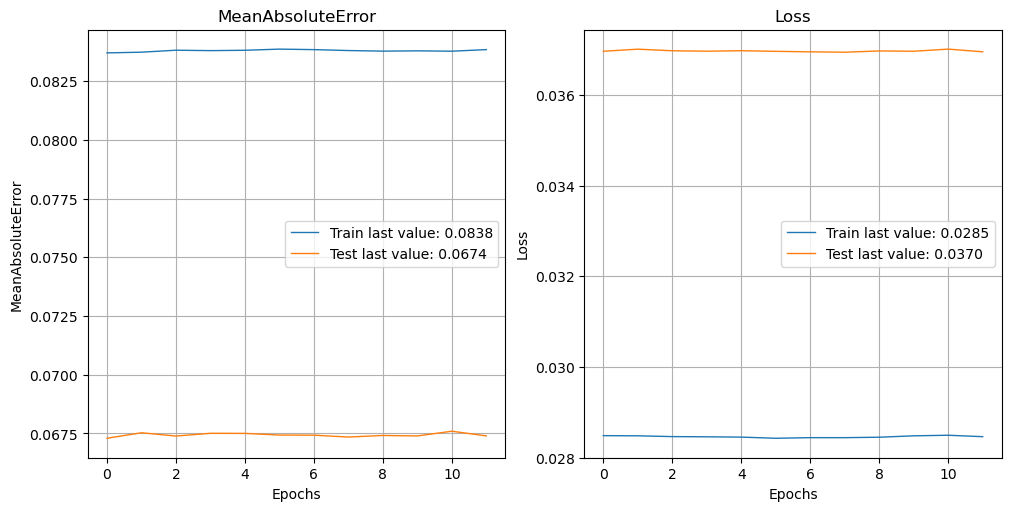

In [ ]:
y_tilde=E.values+np.tile(training_sample['R1M_Usd'].values.reshape(-1,1),nb_mods) # 예측 훈련 ~ 오차 + actual = 모델 예측값
y_test=E_test.values+np.tile(testing_sample['R1M_Usd'].values.reshape(-1,1),nb_mods) # 테스트
fit_NN_stack=model_stack.fit(y_tilde, NN_train_labels, batch_size=512, epochs=12, verbose=1, validation_data=(y_test, NN_test_labels))
from plot_keras_history import show_history
show_history(fit_NN_stack)

[11.3] 확장
- 앙상블을 사용하지 않는 한 가지 대안: 일련의 거시경제 지표에 대한 간단한 트리를 훈련하는 것
- 특정 경제 상황에서 특정 머신러닝 기반 예측을 사용할지 말지 확인 가능

[11.3.2] 모델 간 상관계수 축소
- 첫 번째 레이어의 상관관계 높으면 앙상블은 쓸모 없음
- 상관관계 줄이는 데 가장 간단, 좋: 학습 샘플 변경

(\*) 훈련 샘플의 하위 집합 구축 방법:
- 무작위 분할 or 결정론적 분할(시간, 자산 간 분할)